In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def estimate_kronecker_factors_from_patches(data, k, device, num_iterations=5):
    """
    data: [N, C, H, W] - Full images
    k: int - The patch size to estimate for
    device: torch.device
    """
    # 1. Extract patches from data: [N, C, k, k, NumPatches]
    # To save memory during estimation, we use a stride and a subset of patches
    patches = F.unfold(data, k, stride=k//2).reshape(data.shape[0], data.shape[1], k, k, -1)
    
    # Flatten N and NumPatches into one batch dimension
    # New shape: [TotalPatches, C, k, k]
    patches = patches.permute(0, 4, 1, 2, 3).reshape(-1, data.shape[1], k, k)
    
    # 2. Initialize factors
    Ch = torch.eye(k, device=device)
    Cw = torch.eye(k, device=device)
    Cc = torch.eye(data.shape[1], device=device)
    
    n_p = patches.shape[0]

    for _ in range(num_iterations):
        # Update Row Correlation (Ch)
        # Reshape to [TotalPatches, k, C*k]
        x_h = patches.permute(0, 2, 1, 3).reshape(n_p, k, -1)
        Ch = torch.einsum('bij,bkj->ik', x_h, x_h) / (n_p * data.shape[1] * k)
        Ch = Ch / (Ch.trace() / k) # Normalize scale
        
        # Update Column Correlation (Cw)
        # Reshape to [TotalPatches, k, C*k]
        x_w = patches.permute(0, 3, 1, 2).reshape(n_p, k, -1)
        Cw = torch.einsum('bij,bkj->ik', x_w, x_w) / (n_p * data.shape[1] * k)
        Cw = Cw / (Cw.trace() / k)
        
        # Update Color Correlation (Cc)
        x_c = patches.reshape(n_p, data.shape[1], -1)
        Cc = torch.einsum('bij,bkj->ik', x_c, x_c) / (n_p * k * k)
        Cc = Cc / (Cc.trace() / data.shape[1])

    return {'Ch': Ch, 'Cw': Cw, 'Cc': Cc}

In [2]:
import torch
import numpy as np

def test_approximation_accuracy(k=8): # Use k=8 for a manageable Full Cov size (192x192)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    C, H, W = 3, 32, 32
    p_dim = C * k * k
    
    # 1. Generate/Load CelebA patches (simulated here for structural demo)
    # In practice, use: patches = F.unfold(celeba_images, k).permute(0, 2, 1).reshape(-1, p_dim)
    num_samples = 5000
    data = torch.randn(num_samples, C, k, k).to(device) 
    # Add some spatial/color correlation to make it realistic
    smooth_filter = torch.ones(1, 1, 3, 3).to(device) / 9.0
    data = F.conv2d(data.view(-1, 1, k, k), smooth_filter, padding=1).view(num_samples, C, k, k)
    
    patches = data.view(num_samples, -1) # [N, p_dim]
    patches -= patches.mean(dim=0)

    # 2. Compute "True" Full Covariance
    C_true = (patches.T @ patches) / (num_samples - 1)
    C_true += 1e-4 * torch.eye(p_dim, device=device) # Stability
    inv_true = torch.linalg.inv(C_true)

    # 3. Compute Kronecker Factors (Power Iteration)
    # We estimate Ch, Cw, Cc such that Ch ⊗ Cw ⊗ Cc ≈ C_true
    factors = estimate_kronecker_factors_from_patches(data, k, device)
    
    Ch = factors['Ch']
    Cw = factors['Cw']
    Cc = factors['Cc']
    
    # Form the Kronecker Inverse
    inv_h = torch.linalg.inv(Ch + 1e-4*torch.eye(k, device=device)).contiguous()
    inv_w = torch.linalg.inv(Cw + 1e-4*torch.eye(k, device=device)).contiguous()
    inv_c = torch.linalg.inv(Cc + 1e-4*torch.eye(3, device=device)).contiguous()
    inv_kron = torch.kron(torch.kron(inv_c, inv_h), inv_w)

    # 4. Compare distances on new unseen 'delta'
    test_deltas = torch.randn(100, p_dim, device=device)
    
    d_true = torch.diag(test_deltas @ inv_true @ test_deltas.T)
    d_kron = torch.diag(test_deltas @ inv_kron @ test_deltas.T)

    rel_error = torch.abs(d_true - d_kron) / d_true
    
    print(f"Results for Patch Size k={k}:")
    print(f"Mean Relative Error: {rel_error.mean().item():.4f}")
    print(f"Max Relative Error:  {rel_error.max().item():.4f}")
    print(f"Correlation (R^2):   {np.corrcoef(d_true.cpu(), d_kron.cpu())[0,1]**2:.4f}")

# Note: estimate_kronecker_factors_from_patches would be the 
# function we discussed in the previous turn.

In [3]:
test_approximation_accuracy(32)

Results for Patch Size k=32:
Mean Relative Error: 76.4299
Max Relative Error:  271.5760
Correlation (R^2):   0.0001


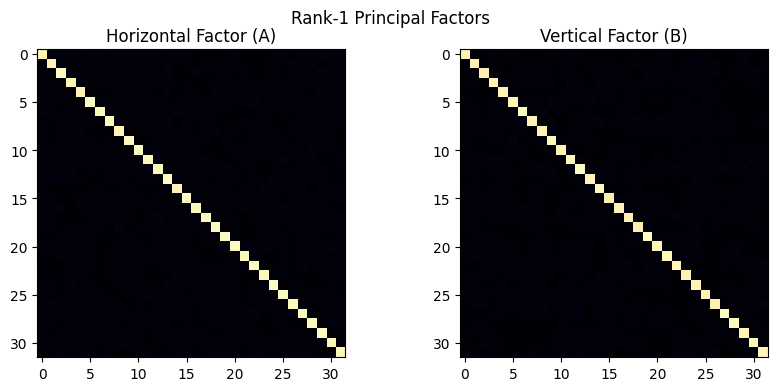


--- CelebA Accuracy Results (k=32) ---
Rank-1 R^2: 0.6342
Rank-3 R^2: 0.6277


In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def safe_kron(a, b):
    """
    A more robust Kronecker product that avoids the internal .view() 
    issues of torch.kron by using explicit expansion.
    """
    a_cont = a.contiguous()
    b_cont = b.contiguous()
    res = a_cont.view(a.size(0), 1, a.size(1), 1) * b_cont.view(1, b.size(0), 1, b.size(1))
    return res.reshape(a.size(0) * b.size(0), a.size(1) * b.size(1)).contiguous()

def estimate_sok_factors(C_true, k, device, rank=2):
    dim = k * k
    # Use reshape and contiguous for rearrangement
    C_res = C_true.reshape(k, k, k, k).permute(0, 2, 1, 3).reshape(dim, dim).contiguous()
    U, S, V = torch.svd(C_res)
    factors = []
    for i in range(rank):
        Ai = (U[:, i].reshape(k, k) * torch.sqrt(S[i])).contiguous()
        Bi = (V[:, i].reshape(k, k) * torch.sqrt(S[i])).contiguous()
        factors.append((Ai, Bi))
    return factors

def plot_kronecker_factors(factors, title="Kronecker Factors"):
    Ch, Cw = factors[0][0].cpu().detach(), factors[0][1].cpu().detach()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(Ch, cmap='magma')
    axes[0].set_title("Horizontal Factor (A)")
    im1 = axes[1].imshow(Cw, cmap='magma')
    axes[1].set_title("Vertical Factor (B)")
    plt.suptitle(title)
    plt.show()

def test_celeba_sok_accuracy(k=16, rank=2, num_images=1000):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    p_dim = 3 * k * k 
    
    # 1. Setup Data
    transform = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])
    try:
        dataset = datasets.CelebA(root='./data', split='train', download=False, transform=transform)
    except:
        dataset = [(torch.randn(3, 32, 32), 0) for _ in range(num_images)]
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    # 2. Extract Patches
    all_patches = []
    for i, (imgs, _) in enumerate(loader):
        if i * 64 >= num_images: break
        patches = F.unfold(imgs.to(device), k, stride=k//2)
        all_patches.append(patches.permute(0, 2, 1).reshape(-1, p_dim))
    
    patches = torch.cat(all_patches, dim=0)
    patches -= patches.mean(dim=0)
    C_true = (patches.T @ patches) / (patches.shape[0] - 1)
    C_true += 1e-3 * torch.eye(p_dim, device=device).contiguous()
    inv_true = torch.linalg.inv(C_true)

    # 3. Approximations
    C_spatial = C_true[:k*k, :k*k].contiguous()
    eye3 = torch.eye(3, device=device).contiguous()
    
    # Rank-1
    f1 = estimate_sok_factors(C_spatial, k, device, rank=1)
    plot_kronecker_factors(f1, title="Rank-1 Principal Factors")
    
    K1 = safe_kron(f1[0][0], f1[0][1])
    spatial_inv1 = torch.linalg.inv(K1 + 1e-3*torch.eye(k*k, device=device).contiguous())
    inv_kron1 = safe_kron(eye3, spatial_inv1)

    # Rank-R (SoK)
    fR = estimate_sok_factors(C_spatial, k, device, rank=rank)
    C_sok_spatial = torch.zeros(k*k, k*k, device=device)
    for Ai, Bi in fR:
        C_sok_spatial += safe_kron(Ai, Bi)
    
    spatial_invR = torch.linalg.inv(C_sok_spatial + 1e-3*torch.eye(k*k, device=device).contiguous())
    inv_sok = safe_kron(eye3, spatial_invR)

    # 4. Accuracy
    test_deltas = torch.randn(200, p_dim, device=device)
    d_true = torch.diag(test_deltas @ inv_true @ test_deltas.T)
    d_r1 = torch.diag(test_deltas @ inv_kron1 @ test_deltas.T)
    d_sok = torch.diag(test_deltas @ inv_sok @ test_deltas.T)

    r2_r1 = np.corrcoef(d_true.cpu().numpy(), d_r1.cpu().numpy())[0,1]**2
    r2_sok = np.corrcoef(d_true.cpu().numpy(), d_sok.cpu().numpy())[0,1]**2

    print(f"\n--- CelebA Accuracy Results (k={k}) ---")
    print(f"Rank-1 R^2: {r2_r1:.4f}")
    print(f"Rank-{rank} R^2: {r2_sok:.4f}")

test_celeba_sok_accuracy(k=32, rank=3)


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


class ArbitraryNoiseCovarianceLocalScore(nn.Module):
    """Local score module that takes an arbitrary noise covariance matrix.
    Inverts the patch covariance via SVD, clamping singular values below
    min_singular_value to that value before inverting."""
    def __init__(self, dataset,
                 noise_covariance,
                 kernel_size=3,
                 batch_size=64,
                 schedule=None,
                 max_samples=None,
                 min_singular_value=1e-6,
                 **kwargs):
        super().__init__()
        self.dataset = dataset
        self.trainloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)
        self.schedule = schedule
        self.kernel_size = kernel_size
        self.max_samples = max_samples
        self.min_singular_value = min_singular_value
        self.noise_covariance = noise_covariance
        self._precision_cache = {}

    def _get_precision_for_k(self, k, device):
        """Invert patch covariance for scale k via SVD with min_singular_value clipping."""
        if k in self._precision_cache and self._precision_cache[k].device == device:
            return self._precision_cache[k]
        P = 3 * k * k
        C = self.noise_covariance[:P, :P].to(device)
        U, S, Vh = torch.linalg.svd(C)
        S_clipped = S.clamp(min=self.min_singular_value)
        inv_S = 1.0 / S_clipped
        precision = (Vh.T * inv_S.unsqueeze(0)) @ U.T
        if precision.dtype != self.noise_covariance.dtype:
            precision = precision.to(self.noise_covariance.dtype)
        self._precision_cache[k] = precision
        return precision

    def compute_exp_args(self, x_patches, image_patches, k, bt, at, device):
        b, c_dim, L = x_patches.shape
        bsize = image_patches.shape[0]
        delta = x_patches[:, None] - at * image_patches[None]  # [b, bsize, P, N] P=3*k*k, N=num_patches
        prec_full = self._get_precision_for_k(k, device)
        left = torch.einsum('bnqN,pq->bnpN', delta, prec_full)
        dist_sq = (left * delta).sum(dim=2)
        return -dist_sq / (2 * bt**2)

    def forward(self, t, x, label=None, device=None, k=None):
        if device is None: device = x.device
        if k is None: k = self.kernel_size

        b, c, h, w = x.shape
        bt = (self.schedule(t))**0.5
        at = (1 - self.schedule(t))**0.5

        # Query patches: [b, 3*k*k, h*w]
        x_patches = F.unfold(x, k, padding=k//2)

        numerator = torch.zeros_like(x)
        denominator = torch.zeros(b, h, w, device=device)
        subtraction = None
        total_samps = 0

        for images, labels in self.trainloader:
            if label is not None:
                images = images[(labels == label).squeeze()]
            if images.shape[0] == 0: continue

            images = images.to(device)
            bsize = images.shape[0]
            total_samps += bsize
            if self.max_samples and total_samps > self.max_samples: break

            target_patches = F.unfold(images, k, padding=k//2)
            exp_args = self.compute_exp_args(x_patches, target_patches, k, bt, at, device)
            exp_args = exp_args.view(b, bsize, h, w)

            # Log-Sum-Exp Stability
            if subtraction is None:
                subtraction = torch.amax(exp_args, dim=(0, 1), keepdim=True)
            else:
                new_sub = torch.amax(exp_args, dim=(0, 1), keepdim=True)
                subtraction = torch.maximum(subtraction, new_sub)
            
            exp_vals = torch.exp(exp_args - subtraction)
            pwise_diffs = x[:, None] - at * images[None] 
            
            numerator += torch.sum(exp_vals[:, :, None, :, :] * pwise_diffs, dim=1)
            denominator += torch.sum(exp_vals, dim=1)

        return -numerator / (denominator[:, None] + 1e-8) / bt**2

    def forward_with_posterior_stats(self, t, x, label=None, device=None, k=None):
        """Returns (score, E_x0, entropy_map, max_prob_map). Posterior is over training images."""
        if device is None: device = x.device
        if k is None: k = self.kernel_size

        b, c, h, w = x.shape
        bt = (self.schedule(t))**0.5
        at = (1 - self.schedule(t))**0.5
        bt = bt.to(device)
        at = at.to(device)

        x_patches = F.unfold(x, k, padding=k//2)
        numerator = torch.zeros_like(x)
        denominator = torch.zeros(b, h, w, device=device)
        sum_exp_times_log = torch.zeros(b, h, w, device=device)
        running_max_exp = torch.zeros(b, h, w, device=device)
        subtraction = None
        total_samps = 0

        for images, labels in self.trainloader:
            if label is not None:
                images = images[(labels == label).squeeze()]
            if images.shape[0] == 0: continue

            images = images.to(device)
            bsize = images.shape[0]
            total_samps += bsize
            if self.max_samples and total_samps > self.max_samples: break

            target_patches = F.unfold(images, k, padding=k//2)
            exp_args = self.compute_exp_args(x_patches, target_patches, k, bt, at, device)
            exp_args = exp_args.view(b, bsize, h, w)

            if subtraction is None:
                subtraction = torch.amax(exp_args, dim=(0, 1), keepdim=True)
            else:
                new_sub = torch.amax(exp_args, dim=(0, 1), keepdim=True)
                subtraction = torch.maximum(subtraction, new_sub)

            exp_vals = torch.exp(exp_args - subtraction)
            pwise_diffs = x[:, None] - at * images[None]

            numerator += torch.sum(exp_vals[:, :, None, :, :] * pwise_diffs, dim=1)
            denominator += torch.sum(exp_vals, dim=1)
            sum_exp_times_log += torch.sum(exp_vals * (exp_args - subtraction), dim=1)
            running_max_exp = torch.maximum(running_max_exp, torch.amax(exp_vals, dim=1))

        denom = denominator[:, None] + 1e-8
        score = -numerator / denom / bt**2
        # E[x_0 | x_t] = (x_t - E[x_t - at*x_0]) / at = (x_t - numerator/denom) / at
        E_x0 = (x - numerator / denom) / at
        # entropy = -sum w_n log(w_n) = log(Z) - (1/Z)*sum exp_arg_n * exp(exp_arg_n - sub) = log(Z) - sum_exp_times_log/Z
        entropy_map = torch.log(denominator + 1e-8) - sum_exp_times_log / (denominator + 1e-8)
        max_prob_map = running_max_exp / (denominator + 1e-8)

        return score, E_x0, entropy_map, max_prob_map

In [ ]:
class GaussianNoiseProvider:
    """
    Provides N(0, covariance) noise and converts score to velocity for the reverse process.
    Velocity = shrinkage_term + (scaling) * (covariance @ score).
    """
    def __init__(self, covariance, schedule, device=None):
        """
        Args:
            covariance: (D, D) noise covariance matrix (e.g. inverse data cov).
            schedule: callable t -> beta_t (e.g. cosine_noise_schedule).
            device: optional device for cached Cholesky.
        """
        self.covariance = covariance
        self.schedule = schedule
        self.device = device
        self._chol = None

    def _get_cholesky(self, device):
        if self._chol is None or self._chol.device != device:
            C = self.covariance.to(device)
            self._chol = torch.linalg.cholesky(C)
        return self._chol

    def sample(self, batch_size, device, shape=(3, 32, 32)):
        """Sample z ~ N(0, covariance). Returns tensor of shape (batch_size, *shape)."""
        D = self.covariance.shape[0]
        L = self._get_cholesky(device)
        z_flat = (L @ torch.randn(D, batch_size, device=device, dtype=L.dtype)).T
        return z_flat.reshape(batch_size, *shape)

    def score_to_velocity(self, t, x, score, nsteps, device):
        """
        Convert score to velocity: v = shrinkage_term + (scaling) * (covariance @ score).
        t: current time in [0, 1] (e.g. step/nsteps).
        x, score: (B, C, H, W). Returns velocity same shape.
        """
        t_prev = t - 1.0 / nsteps
        if isinstance(t, torch.Tensor):
            t_prev = t_prev.to(device)
        beta_t = self.schedule(t).to(device)
        alpha_t = 1 - beta_t
        beta_t_prev = self.schedule(t_prev).to(device)
        alpha_t_prev = 1 - beta_t_prev

        B, C, H, W = x.shape
        D = C * H * W
        x_flat = x.reshape(B, D)
        score_flat = score.reshape(B, D)

        cov = self.covariance.to(device)
        shrinkage = (torch.sqrt(alpha_t_prev / alpha_t) - 1.0)[:, None]
        scaling = (torch.sqrt(beta_t_prev) - torch.sqrt(alpha_t_prev / alpha_t) * torch.sqrt(beta_t))[:, None]

        shrinkage_term = shrinkage * x_flat
        cov_score = score_flat @ cov.T
        velocity_flat = shrinkage_term + scaling * cov_score
        return velocity_flat.reshape(B, C, H, W)

In [6]:
import sys, os
from glob import glob
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as transforms

sys.path.insert(0, '..')
from src.utils.idealscore import cosine_noise_schedule

# ============================================================
# Load data, compute covariances, build score module (run once)
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# --- Load CelebA-HQ images resized to 32x32 ---
img_dir = '/scratch/users/hshunt/celeba_hq_latents/raw/CelebAMask-HQ/CelebA-HQ-img'
n_images = 5000

img_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

img_files = sorted(glob(os.path.join(img_dir, '*.jpg')))[:n_images]
print(f"Loading {len(img_files)} CelebA-HQ images (32x32)...")

images_list = []
for f in tqdm(img_files, desc="Loading"):
    images_list.append(img_transform(Image.open(f).convert('RGB')))
images_tensor = torch.stack(images_list)  # [N, 3, 32, 32]
labels_tensor = torch.zeros(len(images_list), dtype=torch.long)
print(f"Images: {images_tensor.shape}, range: [{images_tensor.min():.2f}, {images_tensor.max():.2f}]")

celeba_dataset = torch.utils.data.TensorDataset(images_tensor, labels_tensor)

# --- Full data covariance and noise covariance for score module and sampling ---
# Noise is drawn from N(0, C_data^{-1}), so we need (L^T)^{-1} for sampling.
print("\nComputing full data covariance (3072 x 3072)...")
flat = images_tensor.view(images_tensor.shape[0], -1).to(device)
flat = flat - flat.mean(dim=0, keepdim=True)
C_full = (flat.T @ flat) / (flat.shape[0] - 1)
C_full += 1e-5 * torch.eye(C_full.shape[0], device=device)
L_chol = torch.linalg.cholesky(C_full)  # C_full = L L^T
print(f"  Cholesky factor: {L_chol.shape}")

# Noise covariance = C_data^{-1} (inverse of data covariance)
print("Computing noise covariance (inverse of data covariance)...")
noise_covariance = torch.cholesky_inverse(L_chol).cpu()
print(f"  Noise covariance: {noise_covariance.shape}")

# --- Gaussian noise provider (sample from N(0, cov) and score -> velocity) ---
noise_provider = GaussianNoiseProvider(noise_covariance, cosine_noise_schedule)
print("Noise provider ready.")

# --- Load pre-calibrated kernel size schedule ---
scales = torch.load('../checkpoints/scales_CelebA_ResNet_zeros.pt', map_location='cpu', weights_only=False)
nsteps = len(scales)
print(f"\nKernel schedule ({nsteps} steps): {scales}")

# --- Build score module (arbitrary noise covariance, SVD-based inverse) ---
max_samples = 2000
hybrid_score = ArbitraryNoiseCovarianceLocalScore(
    dataset=celeba_dataset,
    noise_covariance=noise_covariance,
    kernel_size=scales[0],
    batch_size=64,
    schedule=cosine_noise_schedule,
    max_samples=max_samples,
    min_singular_value=1e-6,
)
print("Score module ready.")

Device: cuda
Loading 5000 CelebA-HQ images (32x32)...


Loading: 100%|██████████| 5000/5000 [00:26<00:00, 187.01it/s]


Images: torch.Size([5000, 3, 32, 32]), range: [-1.00, 1.00]

Computing Kronecker covariance factors (k=32)...
  Ch: torch.Size([32, 32]), Cw: torch.Size([32, 32]), Cc: torch.Size([3, 3])

Computing full data covariance (3072 x 3072)...
  Cholesky factor: torch.Size([3072, 3072])

Kernel schedule (20 steps): [3, 3, 3, 5, 5, 5, 5, 5, 7, 7, 9, 9, 9, 11, 11, 11, 13, 15, 19, 19]
Score module ready.


Colored noise stats: mean=-0.001, std=106.509

Generating 4 samples (20 steps)...
  Sample 1/4  step 15/20  t=0.750  k=11
  Sample 1/4  step 10/20  t=0.500  k=9
  Sample 1/4  step 5/20  t=0.250  k=5
  Sample 1 done.
  Sample 2/4  step 15/20  t=0.750  k=11
  Sample 2/4  step 10/20  t=0.500  k=9
  Sample 2/4  step 5/20  t=0.250  k=5
  Sample 2 done.
  Sample 3/4  step 15/20  t=0.750  k=11
  Sample 3/4  step 10/20  t=0.500  k=9
  Sample 3/4  step 5/20  t=0.250  k=5
  Sample 3 done.
  Sample 4/4  step 15/20  t=0.750  k=11
  Sample 4/4  step 10/20  t=0.500  k=9
  Sample 4/4  step 5/20  t=0.250  k=5
  Sample 4 done.


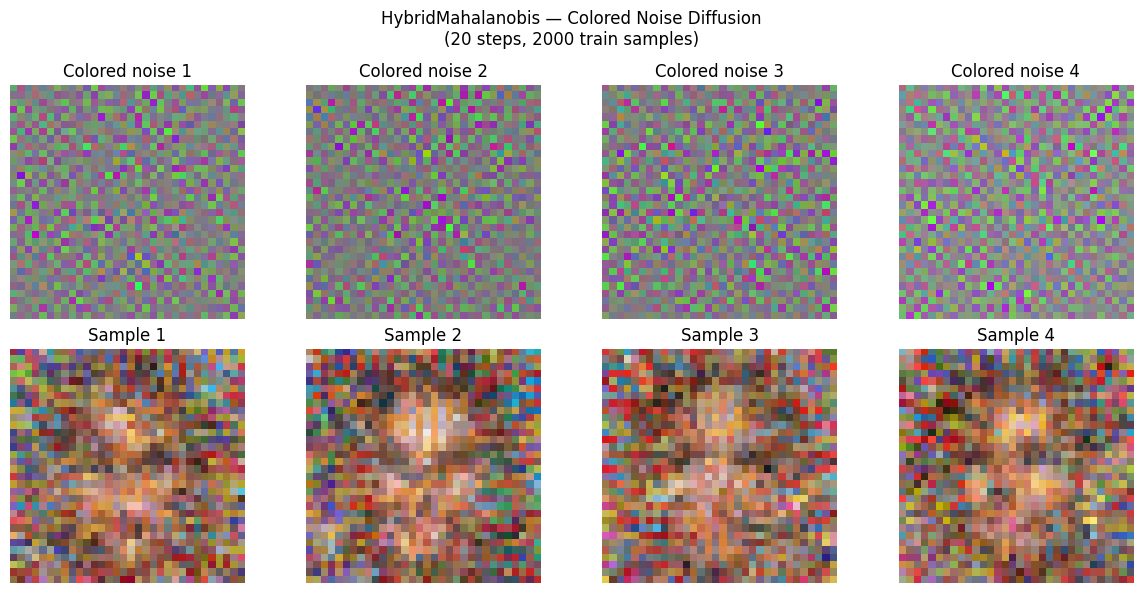

Done!


In [7]:
# ============================================================
# Sample from colored-noise diffusion (re-run without reloading data)
# ============================================================
num_samples = 4
torch.manual_seed(42)

# Initial noise from GaussianNoiseProvider: z ~ N(0, noise_covariance)
z0 = noise_provider.sample(num_samples, device, shape=(3, 32, 32))
print(f"Colored noise stats: mean={z0.mean():.3f}, std={z0.std():.3f}")

print(f"\nGenerating {num_samples} samples ({nsteps} steps)...")
samples = []
for i in range(num_samples):
    x = z0[i:i+1].clone()
    for step in range(nsteps - 1, 0, -1):
        t_val = step / nsteps
        t = torch.tensor([t_val], device=device)
        k = scales[step]

        with torch.no_grad():
            score = hybrid_score(t, x, device=device, k=k)
        velocity = noise_provider.score_to_velocity(t, x, score, nsteps, device)
        x = x + velocity

        if step % 5 == 0:
            print(f"  Sample {i+1}/{num_samples}  step {step}/{nsteps}  t={t_val:.3f}  k={k}")

    samples.append(x.cpu())
    print(f"  Sample {i+1} done.")

samples = torch.cat(samples, dim=0)

# --- Visualize: colored noise -> generated images ---
fig, axes = plt.subplots(2, num_samples, figsize=(3 * num_samples, 6))
for i in range(num_samples):
    # Row 0: initial colored noise (rescaled for display)
    z_img = z0[i].cpu().permute(1, 2, 0).numpy()
    z_img = (z_img - z_img.min()) / (z_img.max() - z_img.min() + 1e-8)
    axes[0, i].imshow(z_img)
    axes[0, i].set_title(f'Colored noise {i+1}')
    axes[0, i].axis('off')

    # Row 1: generated sample
    img = samples[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    img = img.clip(0, 1)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Sample {i+1}')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Initial noise', fontsize=12)
axes[1, 0].set_ylabel('Generated', fontsize=12)
plt.suptitle(f'ArbitraryNoiseCovarianceLocalScore — Colored Noise Diffusion\n({nsteps} steps, {max_samples} train samples)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/hybrid_mahalanobis_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")